# NASDAQ Index Forecasting - ETS Model



## 1. Load Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
# Load NASDAQ index data
for p in [r"C:\Users\17468\Desktop\nasdaq_index.csv", "nasdaq_index.csv", "./nasdaq_index.csv"]:
    try:
        open(p, "rb")
        DATA_PATH = p
        break
    except FileNotFoundError:
        pass
else:
    raise FileNotFoundError("nasdaq_index.csv not found")
df = pd.read_csv(DATA_PATH, parse_dates=["DATE"]).sort_values("DATE").reset_index(drop=True)
df.head(10)

,DATE,nasdaq_close
0,2016-01-04,4903.09
1,2016-01-05,4891.43
2,2016-01-06,4835.76
3,2016-01-07,4689.43
4,2016-01-08,4643.63
5,2016-01-11,4637.99
6,2016-01-12,4685.92
7,2016-01-13,4526.06
8,2016-01-14,4615.00
9,2016-01-15,4488.42


## 2. Data Preprocessing and Train/Test Split

In [3]:
# Create business-day frequency time series
y = df.set_index("DATE")["nasdaq_close"].astype(float)
y_b = y.asfreq("B").interpolate("time").dropna()
y_b.index.freq = "B"

# Train/Test split: use data before 2025-01-01 for training
split_date = pd.Timestamp("2025-01-01")
train = y_b[y_b.index < split_date]
test = y_b[y_b.index >= split_date]

print(f"Train: {len(train)} obs | Test: {len(test)} obs")
print(f"Train period: {train.index.min()} to {train.index.max()}")
print(f"Test period: {test.index.min()} to {test.index.max()}")

Train: 2347 obs | Test: 298 obs
Train period: 2016-01-04 00:00:00 to 2024-12-31 00:00:00
Test period: 2025-01-01 00:00:00 to 2026-02-20 00:00:00


## 3. Part 6: ETS Models 

In [4]:
# ETS Model 1: ETS(A,N,N) - Simple Exponential Smoothing
print("Fitting ETS Models...")
print("=" * 60)

ets_ann = ExponentialSmoothing(train, trend=None, seasonal=None, initialization_method="estimated")
ets_ann_fitted = ets_ann.fit(optimized=True)

print("\nETS(A,N,N) - No trend, No seasonality:")
print("=" * 60)
print(ets_ann_fitted.summary())

Fitting ETS Models...

ETS(A,N,N) - No trend, No seasonality:
                       ExponentialSmoothing Model Results                       
Dep. Variable:             nasdaq_close   No. Observations:                 2347
Model:             ExponentialSmoothing   SSE                       50649026.326
Optimized:                         True   AIC                          23425.974
Trend:                             None   BIC                          23437.496
Seasonal:                          None   AICC                         23425.991
Seasonal Periods:                  None   Date:                 Wed, 25 Feb 2026
Box-Cox:                          False   Time:                         17:44:29
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9404440               

In [5]:
# ETS Model 2: ETS(A,A,N) - Additive trend, No seasonality
ets_aan = ExponentialSmoothing(train, trend='add', seasonal=None, initialization_method="estimated")
ets_aan_fitted = ets_aan.fit(optimized=True)

print("\nETS(A,A,N) - Additive trend, No seasonality:")
print("=" * 60)
print(ets_aan_fitted.summary())


ETS(A,A,N) - Additive trend, No seasonality:
                       ExponentialSmoothing Model Results                       
Dep. Variable:             nasdaq_close   No. Observations:                 2347
Model:             ExponentialSmoothing   SSE                       50549941.915
Optimized:                         True   AIC                          23425.378
Trend:                         Additive   BIC                          23448.422
Seasonal:                          None   AICC                         23425.414
Seasonal Periods:                  None   Date:                 Wed, 25 Feb 2026
Box-Cox:                          False   Time:                         17:44:29
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9383760                alpha          

In [6]:
# ETS Model 3: ETS(A,A,A) - Additive trend, Additive seasonality (5-day trading week)
try:
    ets_aaa = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=5, initialization_method="estimated")
    ets_aaa_fitted = ets_aaa.fit(optimized=True)
    print("\nETS(A,A,A) - Additive trend, Additive 5-day seasonality:")
    print("=" * 60)
    print(ets_aaa_fitted.summary())
    has_aaa = True
except Exception as e:
    print(f"ETS(A,A,A) could not be fitted (seasonality may not improve): {e}")
    has_aaa = False


ETS(A,A,A) - Additive trend, Additive 5-day seasonality:
                       ExponentialSmoothing Model Results                       
Dep. Variable:             nasdaq_close   No. Observations:                 2347
Model:             ExponentialSmoothing   SSE                       50769707.528
Optimized:                         True   AIC                          23445.560
Trend:                         Additive   BIC                          23497.408
Seasonal:                      Additive   AICC                         23445.673
Seasonal Periods:                     5   Date:                 Wed, 25 Feb 2026
Box-Cox:                          False   Time:                         17:44:29
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.9381328          

## 4. Rolling 5-Day Ahead Forecasts (Evaluation)



In [7]:
H, MIN_TRAIN = 5, 200
all_df = y_b.reset_index()
all_df.columns = ["DATE", "nasdaq_close"]
test_start_idx = int(np.searchsorted(all_df["DATE"].values, split_date.to_datetime64(), side="left"))

# Naive baseline: use value from 5 days ago
all_df["naive_5d"] = all_df["nasdaq_close"].shift(H)

# Rolling 5-day ahead forecasts for ETS models
pred_ann = [np.nan] * len(all_df)
pred_aan = [np.nan] * len(all_df)
pred_aaa = [np.nan] * len(all_df)

for i in range(test_start_idx, len(all_df)):
    if i < H:
        continue
    train_series = y_b.iloc[: i - H + 1]
    if len(train_series) < MIN_TRAIN:
        continue
    # ETS(A,N,N)
    m_ann = ExponentialSmoothing(train_series, trend=None, seasonal=None, initialization_method="estimated")
    pred_ann[i] = m_ann.fit(optimized=True).forecast(H).iloc[-1]
    # ETS(A,A,N)
    m_aan = ExponentialSmoothing(train_series, trend="add", seasonal=None, initialization_method="estimated")
    pred_aan[i] = m_aan.fit(optimized=True).forecast(H).iloc[-1]
    # ETS(A,A,A) - optional (may fail for some windows)
    if len(train_series) >= 10:
        try:
            m_aaa = ExponentialSmoothing(train_series, trend="add", seasonal="add", seasonal_periods=5, initialization_method="estimated")
            pred_aaa[i] = m_aaa.fit(optimized=True).forecast(H).iloc[-1]
        except Exception:
            pass

all_df["ets_ann_5d"] = pred_ann
all_df["ets_aan_5d"] = pred_aan
all_df["ets_aaa_5d"] = pred_aaa

test_fc = all_df.loc[all_df["DATE"] >= split_date, ["DATE", "nasdaq_close", "naive_5d", "ets_ann_5d", "ets_aan_5d", "ets_aaa_5d"]].copy()
test_fc.head(10)

,DATE,nasdaq_close,naive_5d,ets_ann_5d,ets_aan_5d,ets_aaa_5d
2347,2025-01-01,19310.79,20031.13,20030.056042,20062.640569,20125.246289
2348,2025-01-02,19280.79,20020.36,20020.961698,20053.614226,20053.733513
2349,2025-01-03,19621.68,19722.03,19740.569513,19773.251600,19827.471955
2350,2025-01-06,19864.98,19486.78,19502.124010,19534.179955,19581.670750
2351,2025-01-07,19489.68,19310.79,19322.168817,19353.664255,19394.098389
2352,2025-01-08,19478.88,19310.79,19311.466717,19342.541444,19382.196468
2353,2025-01-09,19478.88,19280.79,19282.615143,19313.635788,19313.893957
2354,2025-01-10,19161.63,19621.68,19601.431241,19632.364457,19680.200722
2355,2025-01-13,19088.10,19864.98,19849.726444,19881.257403,19934.822088
2356,2025-01-14,19044.39,19489.68,19511.232374,19543.375060,19586.347478


## 5. Forecast Accuracy: MAE, RMSE, MAPE

In [8]:
def mae(a, b): return np.mean(np.abs(a - b))
def rmse(a, b): return np.sqrt(np.mean((a - b) ** 2))
def mape(a, b): return np.mean(np.abs((a - b) / np.maximum(a, 1e-10))) * 100

cols = ["naive_5d", "ets_ann_5d", "ets_aan_5d"]
if test_fc["ets_aaa_5d"].notna().sum() > 10:
    cols.append("ets_aaa_5d")

eval_df = test_fc.dropna(subset=cols)
y_true = eval_df["nasdaq_close"].values

metrics_list = []
model_names = ["Naive (5D)", "ETS(A,N,N)", "ETS(A,A,N)"]
col_names = ["naive_5d", "ets_ann_5d", "ets_aan_5d"]
if "ets_aaa_5d" in cols:
    model_names.append("ETS(A,A,A)")
    col_names.append("ets_aaa_5d")

for name, col in zip(model_names, col_names):
    pred = eval_df[col].values
    metrics_list.append({
        "Model": name,
        "MAE": mae(y_true, pred),
        "RMSE": rmse(y_true, pred),
        "MAPE%": mape(y_true, pred)
    })

metrics = pd.DataFrame(metrics_list)
metrics

,Model,MAE,RMSE,MAPE%
0,Naive (5D),426.919832,550.904785,2.138542
1,"ETS(A,N,N)",426.572966,550.133540,2.136837
2,"ETS(A,A,N)",420.983399,548.612431,2.111857
3,"ETS(A,A,A)",419.834541,552.197007,2.108530


## 6. 5-Day Ahead Forecast Evaluation & Visualization

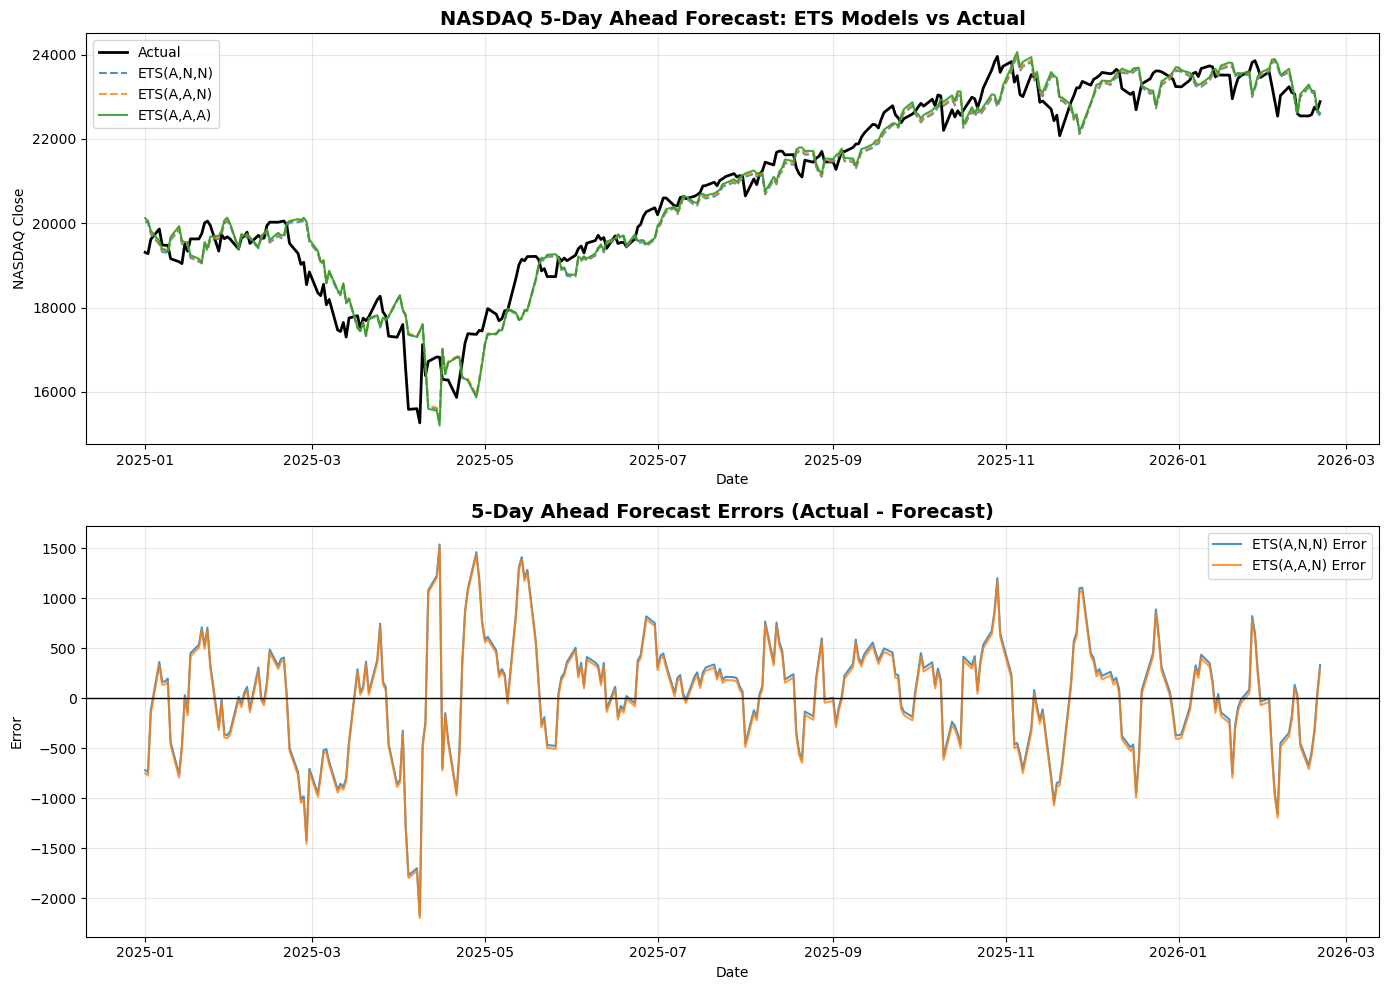

In [9]:
# Plot: Actual vs Forecasts (test period)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(test_fc["DATE"], test_fc["nasdaq_close"], label="Actual", linewidth=2, color='black')
axes[0].plot(test_fc["DATE"], test_fc["ets_ann_5d"], label="ETS(A,N,N)", linestyle='--', alpha=0.8)
axes[0].plot(test_fc["DATE"], test_fc["ets_aan_5d"], label="ETS(A,A,N)", linestyle='--', alpha=0.8)
if "ets_aaa_5d" in test_fc.columns and test_fc["ets_aaa_5d"].notna().sum() > 0:
    axes[0].plot(test_fc["DATE"], test_fc["ets_aaa_5d"], label="ETS(A,A,A)", linestyle='-', alpha=0.9)
axes[0].set_title("NASDAQ 5-Day Ahead Forecast: ETS Models vs Actual", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Date")
axes[0].set_ylabel("NASDAQ Close")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Forecast errors
err_ann = eval_df["nasdaq_close"] - eval_df["ets_ann_5d"]
err_aan = eval_df["nasdaq_close"] - eval_df["ets_aan_5d"]
axes[1].plot(eval_df["DATE"], err_ann, label="ETS(A,N,N) Error", alpha=0.8)
axes[1].plot(eval_df["DATE"], err_aan, label="ETS(A,A,N) Error", alpha=0.8)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title("5-Day Ahead Forecast Errors (Actual - Forecast)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Error")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Select Best Model and Generate Final 5-Day Ahead Forecast

In [10]:
best_row = metrics.sort_values("RMSE").iloc[0]
best_model_name = best_row["Model"]
print(f"Best ETS model (by RMSE): {best_model_name}")

Best ETS model (by RMSE): ETS(A,A,N)


In [11]:
# Fit final model on full history and forecast next 5 trading days
if "ETS(A,N,N)" in best_model_name:
    final_model = ExponentialSmoothing(y_b, trend=None, seasonal=None, initialization_method="estimated")
elif "ETS(A,A,A)" in best_model_name:
    final_model = ExponentialSmoothing(y_b, trend="add", seasonal="add", seasonal_periods=5, initialization_method="estimated")
else:
    final_model = ExponentialSmoothing(y_b, trend="add", seasonal=None, initialization_method="estimated")

final_fit = final_model.fit(optimized=True)
future_5 = final_fit.forecast(5)

print(f"Final 5-Day Ahead Forecast ({best_model_name}):")
display(pd.DataFrame({"ETS_Forecast_next5": future_5}))

Final 5-Day Ahead Forecast (ETS(A,A,N)):


,ETS_Forecast_next5
2026-02-23,22878.596904
2026-02-24,22885.380249
2026-02-25,22892.163593
2026-02-26,22898.946938
2026-02-27,22905.730283


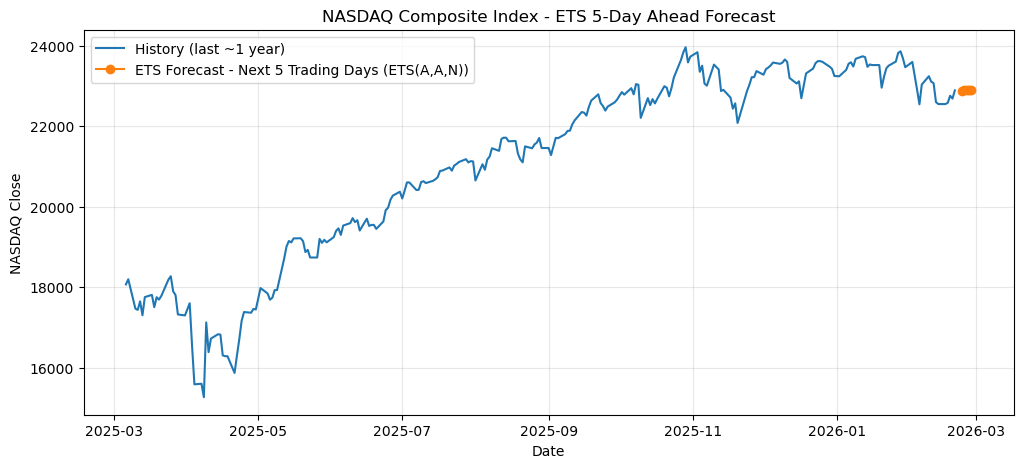

In [12]:
# Visualize final forecast
hist = y_b.iloc[-252:]
plt.figure(figsize=(12, 5))
plt.plot(hist.index, hist.values, label="History (last ~1 year)")
plt.plot(future_5.index, future_5.values, marker='o', label=f"ETS Forecast - Next 5 Trading Days ({best_model_name})")
plt.legend()
plt.title("NASDAQ Composite Index - ETS 5-Day Ahead Forecast")
plt.xlabel("Date")
plt.ylabel("NASDAQ Close")
plt.grid(True, alpha=0.3)
plt.show()